# Covariance

Let $x$ be a continuous random variable with mean $\mu_x$ and variance $\sigma_x^2$, and $y$ be a continuous random variable with mean $\mu_y$ and variance $\sigma_y^2$.

**Covariance** $\sigma_{xy}$ measures the expectation of the product of deviations of $x$ and $y$ from their respective means:

$$\sigma_{xy} = E[(x - \mu_x)(y - \mu_y)] = \int\!\int (x - \mu_x)(y - \mu_y)\, p(x, y)\, dx\, dy$$

where $p(x, y)$ is the joint PDF.

| Sign | Meaning |
|---|---|
| $\sigma_{xy} > 0$ | $x$ and $y$ tend to move **together** (positive relationship) |
| $\sigma_{xy} < 0$ | $x$ and $y$ tend to move **oppositely** (negative relationship) |
| $\sigma_{xy} = 0$ | $x$ and $y$ are **uncorrelated** (no linear relationship) |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from scipy.integrate import dblquad

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'font.size':        11,
})

## Numerical Verification

Using a bivariate Normal distribution with known covariance, we verify the formula numerically:

$$\sigma_{xy} = \iint (x - \mu_x)(y - \mu_y)\, p(x, y)\, dx\, dy$$

In [2]:
mu_x, mu_y   = 170.0, 65.0
sig_x, sig_y = 10.0,  8.0
cov_xy       = 40.0           # analytic covariance

mean = [mu_x, mu_y]
cov_matrix = [[sig_x**2, cov_xy],
              [cov_xy,   sig_y**2]]

dist = multivariate_normal(mean=mean, cov=cov_matrix)

# Numerical covariance via double integral
# Use finite bounds: ±5σ around each mean
lo_x, hi_x = mu_x - 5*sig_x, mu_x + 5*sig_x
lo_y, hi_y = mu_y - 5*sig_y, mu_y + 5*sig_y

def integrand(y, x):
    return (x - mu_x) * (y - mu_y) * dist.pdf([x, y])

cov_num, _ = dblquad(integrand, lo_x, hi_x, lo_y, hi_y)

print(f"μ_x = {mu_x},  σ_x = {sig_x},  σ_x² = {sig_x**2}")
print(f"μ_y = {mu_y},  σ_y = {sig_y},  σ_y² = {sig_y**2}")
print()
print(f"Numerical σ_xy = ∬(x−μ_x)(y−μ_y)p(x,y)dxdy = {cov_num:.6f}")
print(f"Analytic  σ_xy =                               {cov_xy:.6f}")
print(f"Match: {np.isclose(cov_num, cov_xy, rtol=1e-4)}")

μ_x = 170.0,  σ_x = 10.0,  σ_x² = 100.0
μ_y = 65.0,  σ_y = 8.0,  σ_y² = 64.0

Numerical σ_xy = ∬(x−μ_x)(y−μ_y)p(x,y)dxdy = 39.998768
Analytic  σ_xy =                               40.000000
Match: True


## Positive, Negative, and Zero Covariance

Three bivariate Normal distributions with the same marginal variances but different covariances.

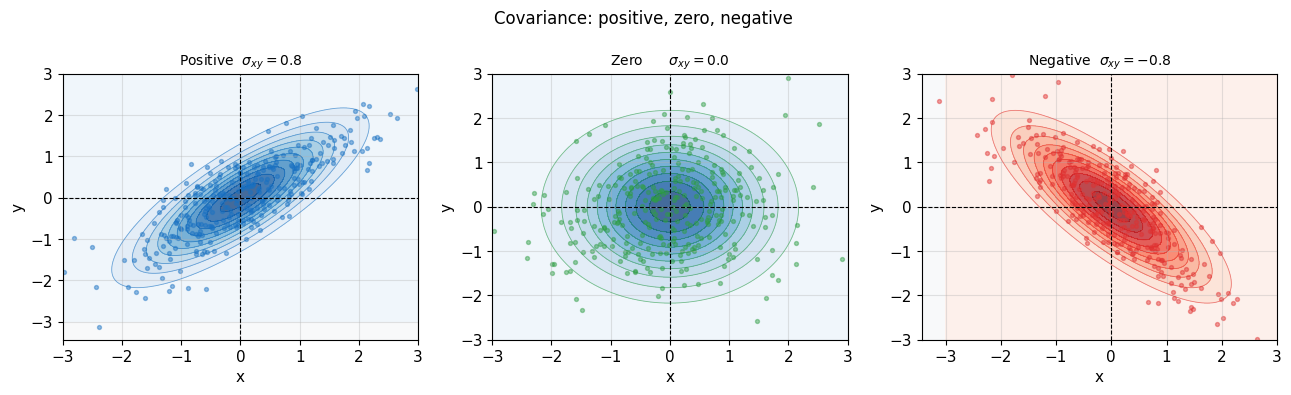

In [3]:
sx, sy = 1.0, 1.0
cases = [
    {'cov': 0.8,  'title': r'Positive  $\sigma_{xy}=0.8$',  'color': '#1971c2'},
    {'cov': 0.0,  'title': r'Zero      $\sigma_{xy}=0.0$',  'color': '#2f9e44'},
    {'cov': -0.8, 'title': r'Negative  $\sigma_{xy}=-0.8$', 'color': '#e03131'},
]

x_g = np.linspace(-3, 3, 120)
y_g = np.linspace(-3, 3, 120)
X, Y = np.meshgrid(x_g, y_g)
pos = np.dstack([X, Y])

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, cfg in zip(axes, cases):
    d = multivariate_normal(mean=[0, 0], cov=[[sx**2, cfg['cov']], [cfg['cov'], sy**2]])
    Z = d.pdf(pos)
    ax.contourf(X, Y, Z, levels=10, cmap='Blues' if cfg['cov'] >= 0 else 'Reds', alpha=0.75)
    ax.contour(X, Y, Z, levels=10, colors=cfg['color'], linewidths=0.6, alpha=0.6)

    # Scatter from distribution
    rng = np.random.default_rng(42)
    samples = d.rvs(size=300, random_state=rng)
    ax.scatter(samples[:, 0], samples[:, 1], s=8, color=cfg['color'], alpha=0.45)

    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.axvline(0, color='black', lw=0.8, ls='--')
    ax.set_title(cfg['title'], fontsize=10)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.suptitle('Covariance: positive, zero, negative', fontsize=12)
plt.tight_layout()
plt.show()

## Covariance Matrix

For a pair of random variables, the covariance matrix $\Sigma$ captures all pairwise relationships:

$$\Sigma = \begin{bmatrix} \sigma_x^2 & \sigma_{xy} \\ \sigma_{xy} & \sigma_y^2 \end{bmatrix}$$

- Diagonal entries: **variances** ($\sigma_x^2$, $\sigma_y^2$)
- Off-diagonal entries: **covariance** ($\sigma_{xy}$) — symmetric

In [4]:
Sigma = np.array([[sig_x**2, cov_xy],
                  [cov_xy,   sig_y**2]])

print("Covariance matrix Σ:")
print(f"  [ σ_x²    σ_xy ]   [ {Sigma[0,0]:.1f}   {Sigma[0,1]:.1f} ]")
print(f"  [ σ_xy    σ_y² ] = [ {Sigma[1,0]:.1f}   {Sigma[1,1]:.1f} ]")
print()
print(f"  σ_x²  = {Sigma[0,0]:.1f}  (variance of x)")
print(f"  σ_y²  = {Sigma[1,1]:.1f}  (variance of y)")
print(f"  σ_xy  = {Sigma[0,1]:.1f}  (covariance)  →  symmetric: Σ = Σᵀ: {np.allclose(Sigma, Sigma.T)}")

Covariance matrix Σ:
  [ σ_x²    σ_xy ]   [ 100.0   40.0 ]
  [ σ_xy    σ_y² ] = [ 40.0   64.0 ]

  σ_x²  = 100.0  (variance of x)
  σ_y²  = 64.0  (variance of y)
  σ_xy  = 40.0  (covariance)  →  symmetric: Σ = Σᵀ: True


## Summary

| Concept | Formula |
|---|---|
| **Covariance** | $\sigma_{xy} = E[(x-\mu_x)(y-\mu_y)] = \iint (x-\mu_x)(y-\mu_y)\,p(x,y)\,dx\,dy$ |
| $\sigma_{xy} > 0$ | $x$ and $y$ increase together |
| $\sigma_{xy} < 0$ | one increases as the other decreases |
| $\sigma_{xy} = 0$ | no linear relationship (uncorrelated) |
| **Covariance matrix** | $\Sigma = \begin{bmatrix}\sigma_x^2 & \sigma_{xy}\\\sigma_{xy} & \sigma_y^2\end{bmatrix}$ — symmetric, diagonal = variances |

> Note: $\sigma_{xy} = 0$ does **not** imply independence — only the absence of a *linear* relationship.